In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [4]:
df.columns.tolist()


['Year',
 'Month',
 'Region',
 'Model',
 'Estimated_Deliveries',
 'Production_Units',
 'Avg_Price_USD',
 'Battery_Capacity_kWh',
 'Range_km',
 'CO2_Saved_tons',
 'Source_Type',
 'Charging_Stations']

In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [6]:
# Tesla Sales & Production Analysis
## Data Cleaning and Exploratory Data Analysis

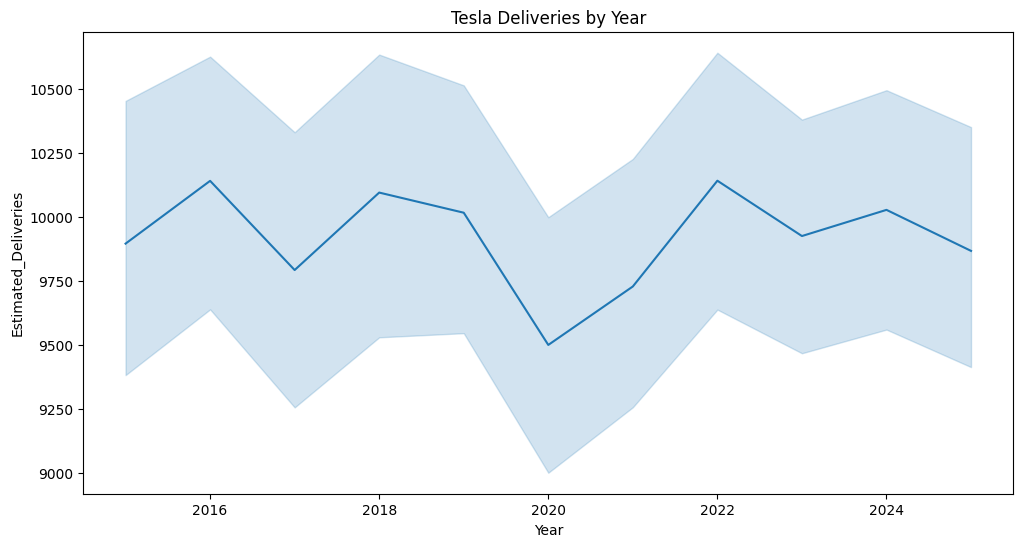

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Year', y='Estimated_Deliveries')
plt.title("Tesla Deliveries by Year")
plt.show()

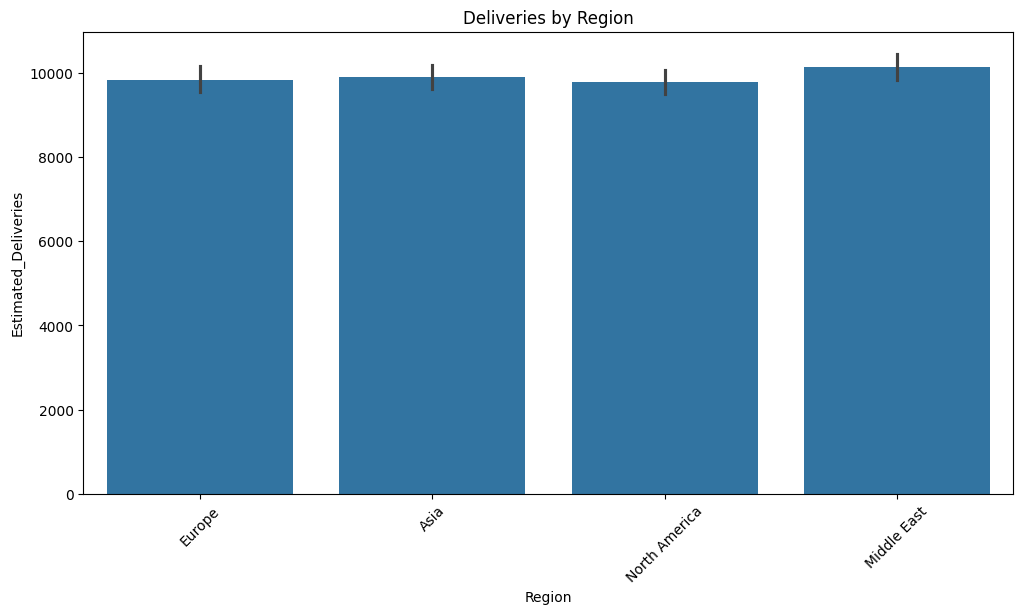

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Region', y='Estimated_Deliveries')
plt.title("Deliveries by Region")
plt.xticks(rotation=45)
plt.show()

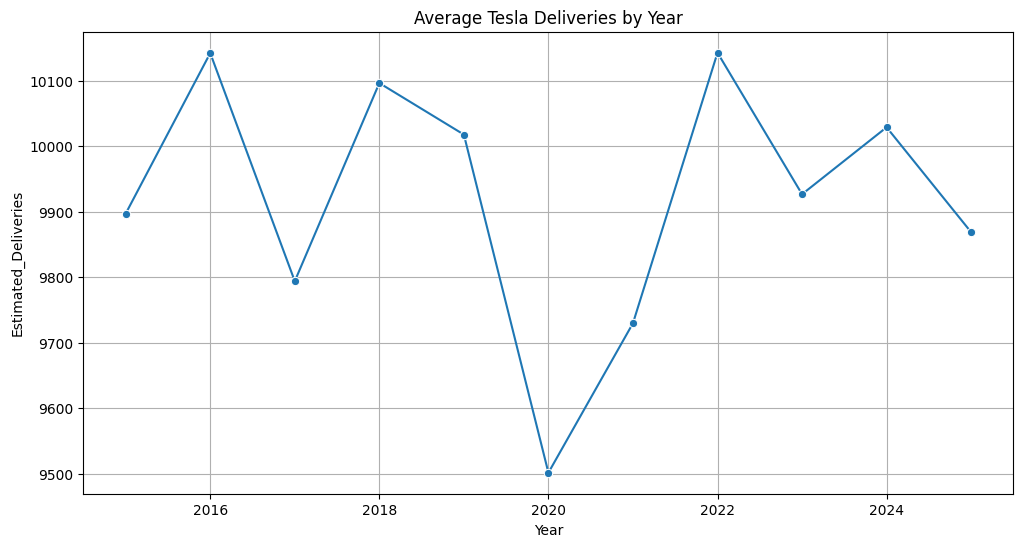

In [9]:
yearly = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x='Year', y='Estimated_Deliveries', marker='o')
plt.title('Average Tesla Deliveries by Year')
plt.grid(True)
plt.show()

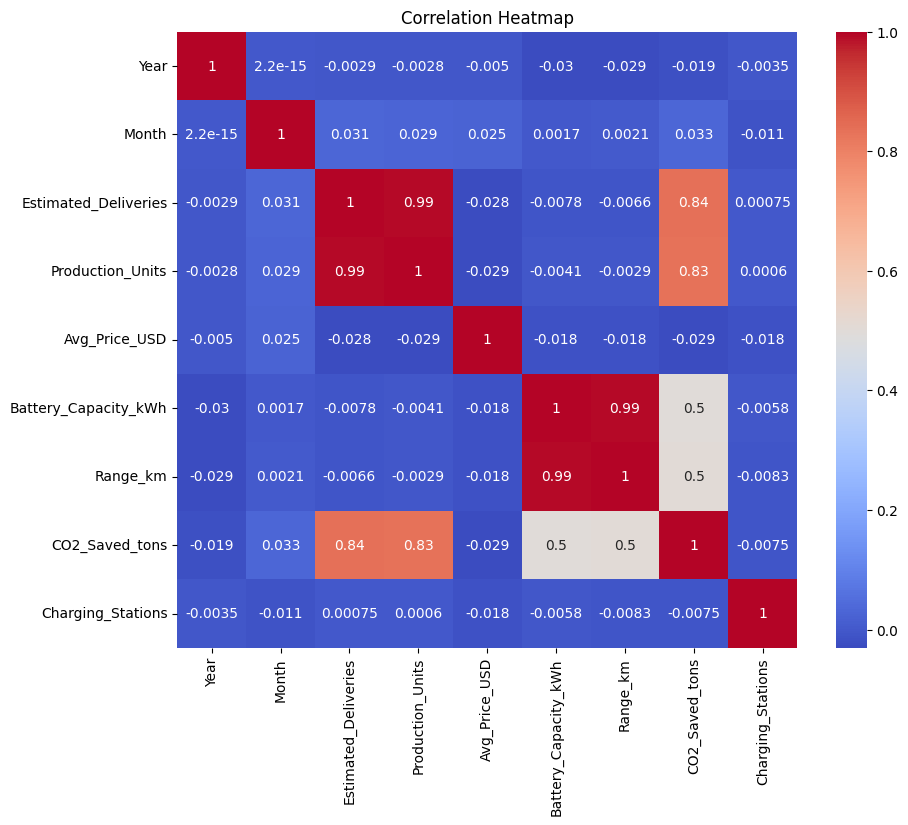

In [10]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

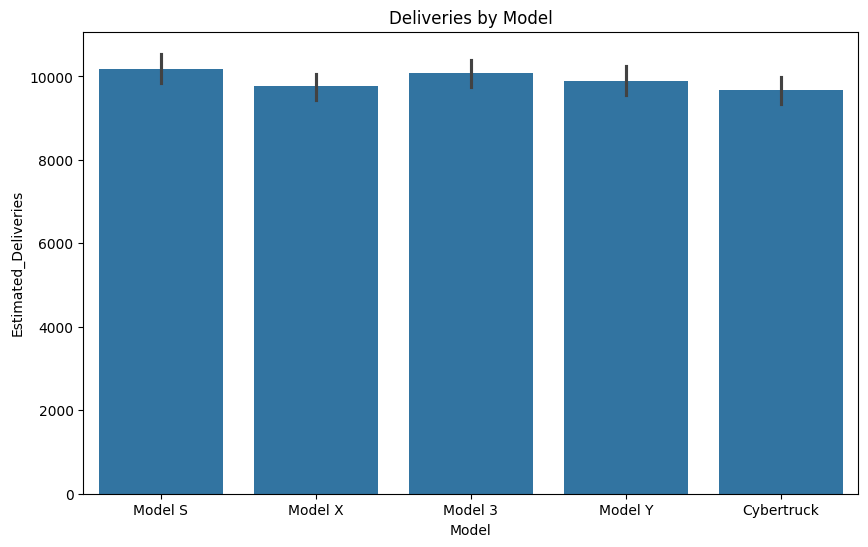

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Model',
    y='Estimated_Deliveries'
)

plt.title("Deliveries by Model")
plt.show()

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

In [13]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_ml['Region'] = le_region.fit_transform(df_ml['Region'])
df_ml['Model'] = le_model.fit_transform(df_ml['Model'])
df_ml['Source_Type'] = le_source.fit_transform(df_ml['Source_Type'])

df_ml.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [14]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Estimated_Deliveries', axis=1)

y = df_ml['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 11)
Testing Shape: (528, 11)


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
pred = model.predict(X_test)

print(pred[:10])

[ 7361.8   9357.63  8942.64  9422.18  8777.07 11708.21 13988.37 13923.76
 10180.63  7877.03]


In [17]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

print("R2 Score :", r2)
print("MAE :", mae)
print("MSE :", mse)

R2 Score : 0.9887505867840798
MAE : 323.46011363636364
MSE : 167686.99473295457


                 Feature  Importance
4       Production_Units    0.990785
8         CO2_Saved_tons    0.002348
7               Range_km    0.001415
5          Avg_Price_USD    0.001338
10     Charging_Stations    0.001170
0                   Year    0.000837
1                  Month    0.000758
3                  Model    0.000469
2                 Region    0.000398
9            Source_Type    0.000321
6   Battery_Capacity_kWh    0.000161


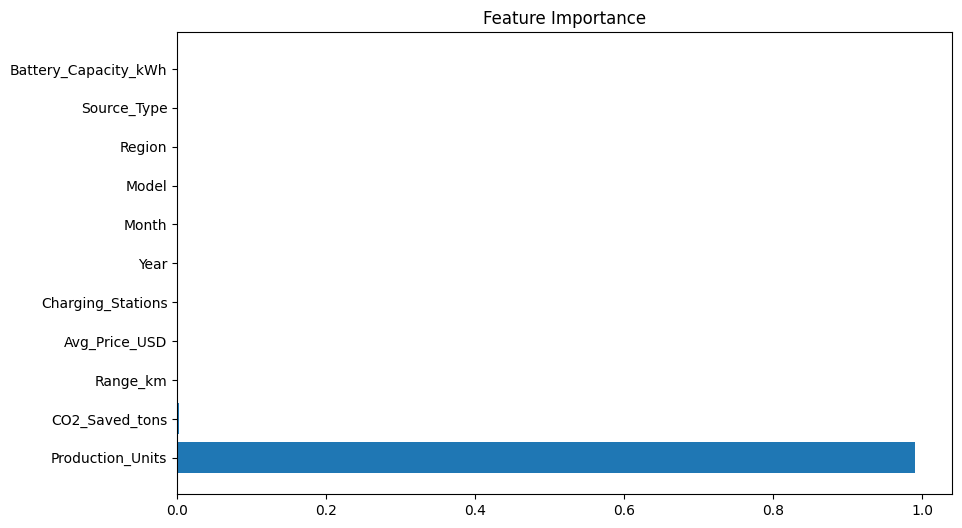

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.title("Feature Importance")
plt.show()

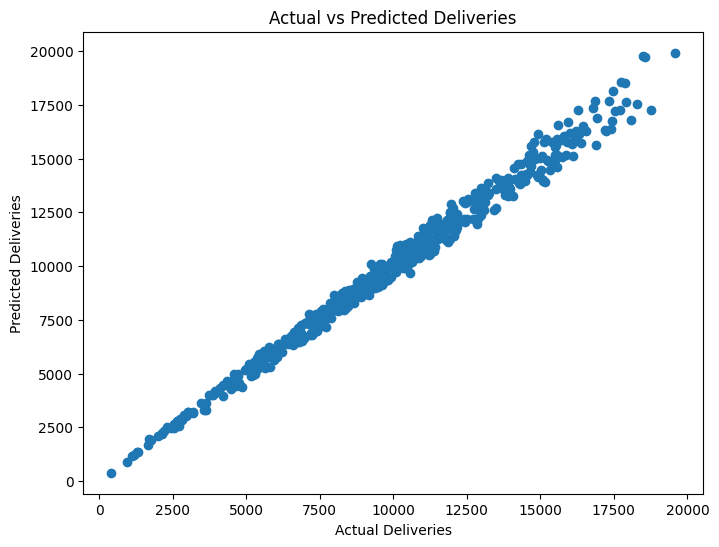

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


# Conclusion

- Successfully built an end-to-end machine learning pipeline on Tesla sales and production data.
- Performed data preprocessing and exploratory data analysis (EDA).
- Applied label encoding for categorical features.
- Trained a Random Forest Regressor model.
- Achieved an R² score of approximately 0.99.
- Production Units was found to be the most influential feature for predicting deliveries.
- The model demonstrated strong predictive performance on the dataset.